=== NØKKELTALL CASE 1 ===
Total energi: 171727.6 MWh
Total inntekt: 57,033,090 kr
Driftstimer: 3816
Antall oppstarter: 79
Gjennomsnittlig effekt i drift: 45.00 MW
             Datetime  MWh  Price_ore_kWh  Power_W  Q_m3s  P_MW
0 2024-01-01 00:00:00  0.0         33.227      0.0    0.0   0.0
1 2024-01-01 01:00:00  0.0         31.990      0.0    0.0   0.0
2 2024-01-01 02:00:00  0.0         29.967      0.0    0.0   0.0
3 2024-01-01 03:00:00  0.0         27.517      0.0    0.0   0.0
4 2024-01-01 04:00:00  0.0         26.988      0.0    0.0   0.0


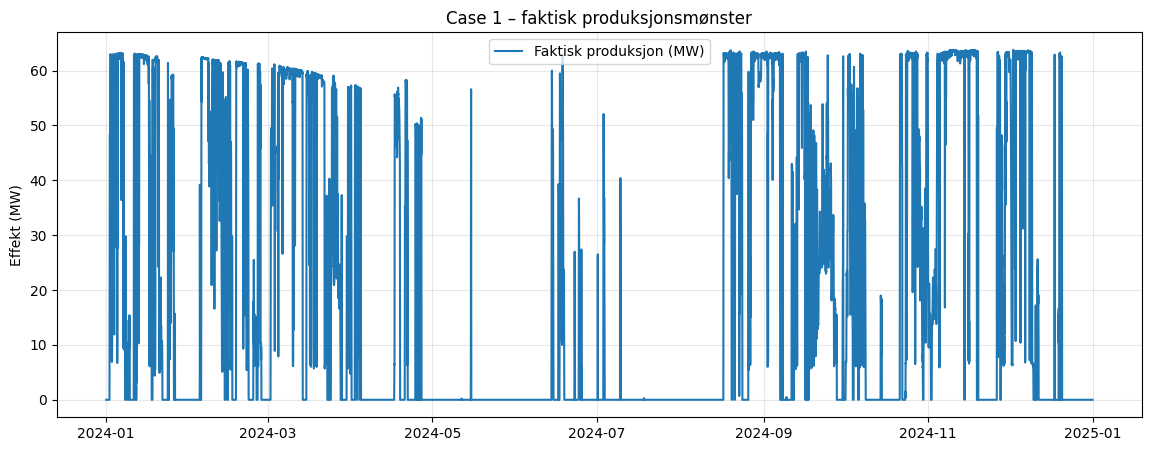

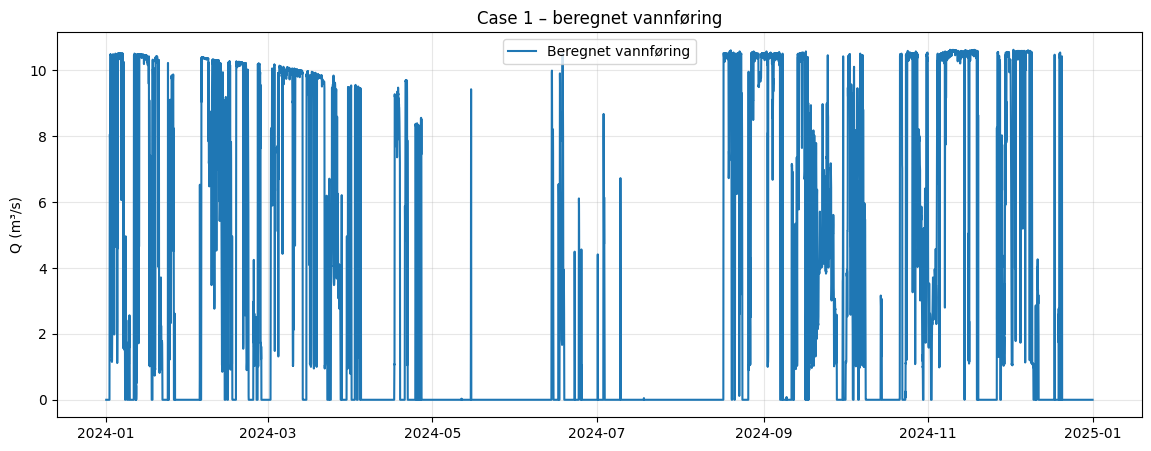

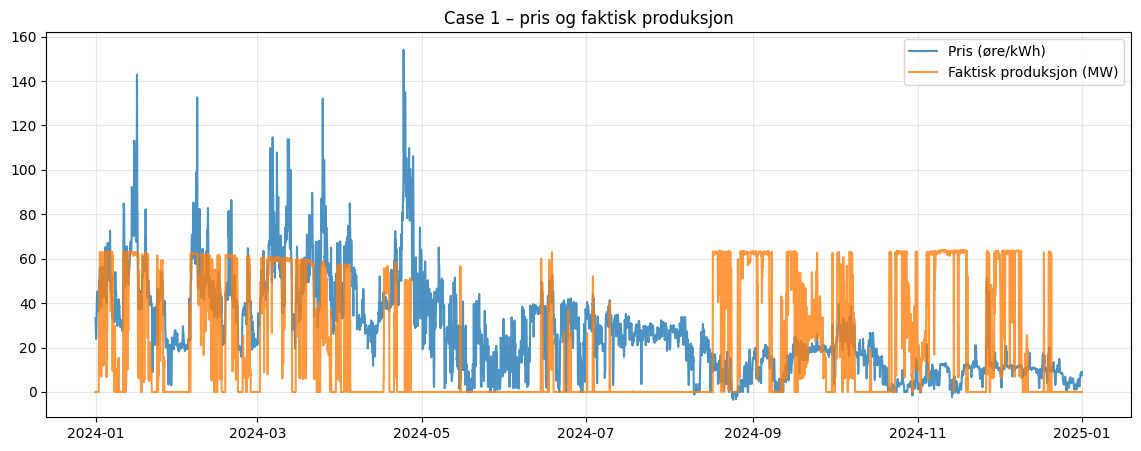

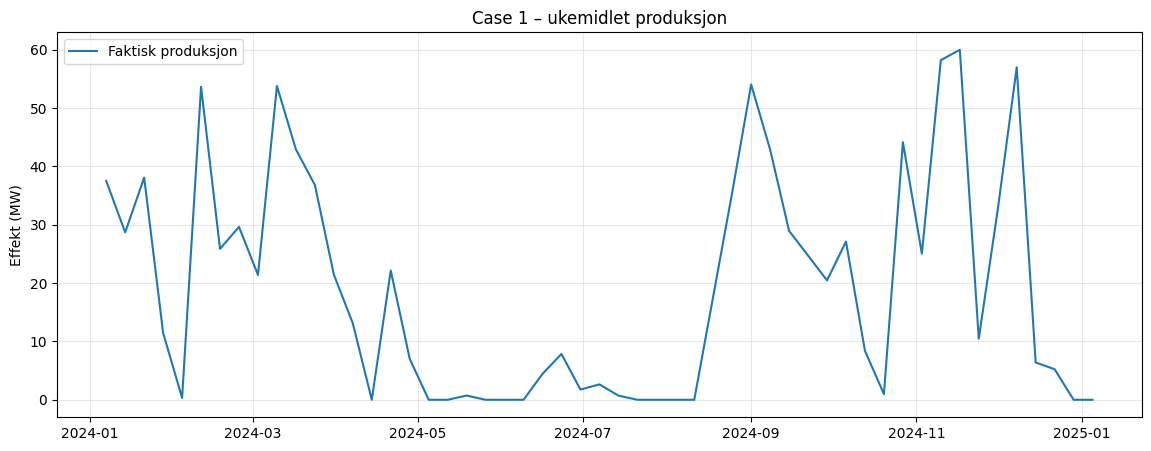

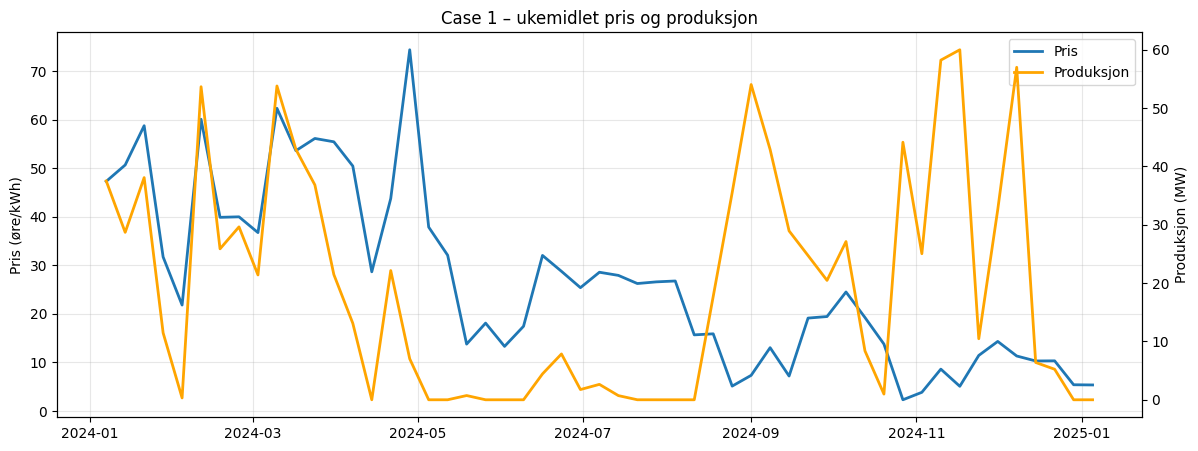

In [4]:
# Case 1. Min code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# CASE 1 – FAKTISK DRIFTSMØNSTER
# --------------------------------------------------

df = pd.read_excel("Sildvik_Produksjon_Pris_2024 (1).xlsx", engine="openpyxl")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["MWh"] = pd.to_numeric(df["MWh"], errors="coerce")
df["Price_ore_kWh"] = pd.to_numeric(df["Price_ore_kWh"], errors="coerce")

df = df.dropna(subset=["Datetime", "MWh", "Price_ore_kWh"]).copy()
df = df.sort_values("Datetime").reset_index(drop=True)

# --------------------------------------------------
# Beregn effekt og vannføring
# --------------------------------------------------

rho = 1000
g = 9.81
H = 680
eta = 0.90

df["P_MW"] = df["MWh"]          # MWh per time = MW
df["Power_W"] = df["P_MW"] * 1e6
df["Q_m3s"] = df["Power_W"] / (eta * rho * g * H)

# --------------------------------------------------
# Nøkkeltall
# --------------------------------------------------

total_energy = df["MWh"].sum()
total_income = (df["MWh"] * df["Price_ore_kWh"] * 1000 / 100).sum()
drift_hours = (df["MWh"] > 0).sum()
starts = ((df["MWh"] > 0) & (df["MWh"].shift(1, fill_value=0) == 0)).sum()
avg_power_when_running = df.loc[df["MWh"] > 0, "P_MW"].mean()

print("=== NØKKELTALL CASE 1 ===")
print(f"Total energi: {total_energy:.1f} MWh")
print(f"Total inntekt: {total_income:,.0f} kr")
print(f"Driftstimer: {drift_hours}")
print(f"Antall oppstarter: {starts}")
print(f"Gjennomsnittlig effekt i drift: {avg_power_when_running:.2f} MW")

print(df.head())

# --------------------------------------------------
# PLOTS CASE 1 – FAKTISK DRIFT
# --------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["P_MW"], label="Faktisk produksjon (MW)")
plt.ylabel("Effekt (MW)")
plt.title("Case 1 – faktisk produksjonsmønster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["Q_m3s"], label="Beregnet vannføring")
plt.title("Case 1 – beregnet vannføring")
plt.ylabel("Q (m³/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["Price_ore_kWh"], label="Pris (øre/kWh)", alpha=0.8)
plt.plot(df["Datetime"], df["P_MW"], label="Faktisk produksjon (MW)", alpha=0.8)
plt.title("Case 1 – pris og faktisk produksjon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plottene under viser ukentlig plott. Ikke nødvendig, man kan ha med

df_plot = df.copy()
df_plot = df_plot.set_index("Datetime")

weekly = df_plot.resample("W").mean(numeric_only=True)

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["P_MW"], label="Faktisk produksjon")
plt.title("Case 1 – ukemidlet produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(14, 5))

ax1 = plt.gca()
ax1.plot(weekly.index, weekly["Price_ore_kWh"], label="Pris", linewidth=2)
ax1.set_ylabel("Pris (øre/kWh)")
ax1.set_title("Case 1 – ukemidlet pris og produksjon")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["P_MW"], label="Produksjon", linewidth=2, color="orange")
ax2.set_ylabel("Produksjon (MW)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()